**Predicting the FIFA World Cup Winner with Machine Learning**

A step-by-step project By the end, we will have trained a real machine learning model on real football data, evaluated it properly, tuned it, and used it to simulate who wins the World Cup 2026.

The 10 steps
1. Understanding the problem: classification vs. regression
2. Downloading the dataset
3. Exploring and cleaning the data
4. A first look at the data (EDA)
5. Engineering a "team strength" feature (Elo ratings)
6. Preparing training and test sets
7. Training your first model
8. Evaluating the model (accuracy, confusion matrix, log loss)
9. Improving the model (fixing class imbalance, hyperparameter tuning)
10. Using the model to simulate the World Cup

**Installing of the essential libraries, pandas, numpy, matplotlib, seaborn, scikit-learn, joblib**

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



**Step 1: Classification or Regression?**

 **Regression** predicts a *continuous number* (e.g. predicting `home_score = 2.3`).
 **Classification** predicts a *category* out of a fixed set of options (e.g. `home_win`, `draw`, `away_win`).

Since what we actually care about is **who wins**, not the exact scoreline, this is a **classification problem**. Specifically, it's *multi-class* classification, because there are 3 possible outcomes.

Side note: a more advanced version of this project predicts the exact scoreline using Poisson regression. We're keeping it to classification here because it's easier and directly answers "who wins?".


**Step 2: Downloading the dataset**
We're using a free, public dataset of every international football match played since 1872, hosted on GitHub as a CSV file.
**Source:** https://github.com/martj42/international_results

`pd.read_csv(path_or_url)` reads a CSV file into a **DataFrame** - pandas' main data structure, basically a table with rows and named columns.
 `parse_dates=["date"]` tells pandas "this column contains dates, convert it to an actual date type" - needed later for sorting/filtering by date.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

DATA_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(DATA_URL, parse_dates=["date"])

df.head()   # shows the first 5 rows


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


A few useful DataFrame attributes for getting bearings on any new dataset:
 `df.shape` -> `(number_of_rows, number_of_columns)`
 `df.columns` -> the list of column names
 `df.dtypes` -> the data type pandas inferred for each column

In [3]:
print("Shape (rows, columns):", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)

Shape (rows, columns): (49520, 9)

Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Data types:
 date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object


~49,500 matches across just 9 columns. A small, tidy dataset. Notice there's no column that directly says "who won",  just `home_score` and `away_score`. That means the classification target (Step 6) isn't handed to us; we'll have to derive it ourselves from the two score columns. Also, `home_elo`-style "team strength" columns don't exist either. That's the whole reason Step 5 (Elo ratings) is necessary rather than optional.

**Step 3: Exploring and cleaning the data**

Real datasets are never ready to use straight away. Before training anything, always check:
1. **Missing values** (nulls)
2. **Duplicate rows**
3. **Incorrect data types**

The syntax
`df.isnull()` returns True/False per cell (True = missing)
`.sum()` adds up the Trues per column
`df.duplicated()` flags exact-copy rows

In [4]:
print("Null values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Null values per column:
date          0
home_team     0
away_team     0
home_score    2
away_score    2
tournament    0
city          0
country       0
neutral       0
dtype: int64

Number of duplicate rows: 0


 Only 4 rows have nulls, and they're concentrated in `home_team`, `away_team`, `home_score`, `away_score` together. Meaning entire rows are incomplete, not scattered single fields. Zero duplicates is also worth noting, it tells you the data source is already deduplicated, so you don't need extra logic in your pipeline.

Let's look at the null rows instead of guessing. `df[condition]` filters a DataFrame: keeps only rows where `condition` is True.
`df.isnull().any(axis=1)` means "is there at least one missing value in this row?"

In [5]:
df[df.isnull().any(axis=1)]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49518,2026-07-18,France,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49519,2026-07-19,Spain,Argentina,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


These turn out to be **future matches that haven't been played yet** hence no score recorded, and for two of them the teams aren't even decided yet (they're placeholders for a final that hadn't been played when this data was pulled). This is a common real-world pattern: "missing" doesn't always mean "broken data", sometimes it means "hasn't happened yet". We can't train on a match with no result, so we drop these, but it's worth understanding *why* and the reasoning before deleting anything.

The syntax
 `df.dropna(subset=[...])` removes rows missing a value in any of the listed columns,
 `.astype(int)` converts a column to whole numbers (scores loaded as decimals because of the earlier nulls),
 `.sort_values("date")` sorts oldest to newest - essential since we'll process matches chronologically,
 `.reset_index(drop=True)` renumbers rows 0, 1, 2, ... after filtering/sorting.


In [6]:
df = df.dropna(subset=["home_team", "away_team", "home_score", "away_score"]).copy() #Instead of rewriting the actual dataframe, we create a copy of the dataframe without the null values in the specified columns.

df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)
df["neutral"] = df["neutral"].astype(int)   # True/False -> 1/0

df = df.sort_values("date").reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Shape after cleaning: (49518, 9)
Remaining nulls: 0


 We only lost 4 rows out of ~49,500 so the cleaning step didn't meaningfully shrink our data. That's worth checking explicitly whenever dropping rows. If cleaning had removed 30% of the dataset, that would be a red flag worth investigating rather than quietly proceeding.

**Why `.copy()`?** Filtering a DataFrame like `df[condition]` sometimes gives you a vie rather than an independent copy. Editing a view can trigger a `SettingWithCopyWarning`. `.copy()` guarantees an independent DataFrame you can safely modify without overriding the original.

**Step 4: A first look at the data (EDA)**

"EDA" = Exploratory Data Analysis, simple summaries and charts before modelling, to build intuition.

The syntax
`np.select(conditions, choices, default)` works like if/elif/else applied to an entire column at once.

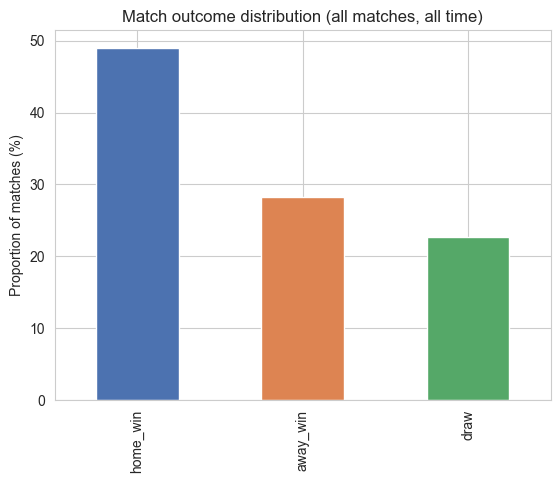

In [7]:
outcome_counts = np.select([df.home_score > df.away_score, df.home_score < df.away_score],["home_win", "away_win"],default="draw")
#If home score is greater than away score, then home_win label, and vice versa for away_win. If neither, then draw.

# .value_counts() counts how often each unique value appears
# normalize=True turns counts into proportions
pd.Series(outcome_counts).value_counts(normalize=True)
#Calculate the proportion of each outcome type (home_win, away_win, draw)


(pd.Series(outcome_counts).value_counts(normalize=True)*100).plot( #Converting the proportions into percentages by multiplying by 100, and then plotting the results
    kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], #X axis is categories, Y is the proportion, the color for each is distinct
    title="Match outcome distribution (all matches, all time)")
plt.ylabel("Proportion of matches (%)")
plt.show()

 Home teams win roughly **twice as often** as away teams so "home advantage" is real, and worth turning into a model feature. Draws are the least common outcome at under a quarter of matches. This single chart already tells us two important design decisions for later: (1) `neutral` venue is a genuinely informative feature, not noise and (2) our classes are **imbalanced**, which will be an issue specifically at Step 8 when we look at how well the model predicts draws.

**Step 5: Engineering a "team strength" feature (Elo ratings)**

Our raw data has team names and scores, but nothing that says "how good is this team *right now*". We build that ourselves which is **feature engineering**.

We'll build a classic **Elo rating system** (same idea as chess ratings):
Every team starts at 1500
After each match, compare the *actual* result to the *expected* result
The winner takes points from the loser; bigger surprises/margins move more points

The syntax
`elo = {}` is a Python **dictionary**: `key -> value` lookup table. We use `team_name -> current_rating`.
`elo.get(team, 1500)` looks up a rating; returns 1500 if the team isn't in the dict yet (first match).
`df.iterrows()` loops through a DataFrame one row at a time so that it is easier to follow when logic depends on a running value.

We will be using the elo formula for calculating elo
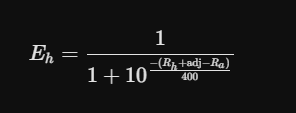

In [8]:
K = 20          # how aggressively ratings move after each match
HOME_ADV = 60   # ratings-point bonus for playing at home (skipped for neutral venues)

elo = {}
home_elo_pre, away_elo_pre = [], []

for _, row in df.iterrows():
    #Retrieve current ratings for both teams; default to 1500 if team hasn't played yet
    h, a = row.home_team, row.away_team
    h_elo, a_elo = elo.get(h, 1500), elo.get(a, 1500)


    #Store pre-match ratings to the list for later DataFrame assignment
    home_elo_pre.append(h_elo)
    away_elo_pre.append(a_elo)

    # Calculate Home Advantage: Add 60 points to the home team's rating if the match isn't at a neutral venue
    adj = HOME_ADV if not row.neutral else 0

    #Calculate Expected Outcome: Uses the Elo probability formula based on the rating difference
    expected_home = 1 / (1 + 10 ** (-((h_elo + adj) - a_elo) / 400)) #h_elo + adj references the difference between home team with advantage of course against away team


    #Convert score results into binary values (1.0, 0.0, or 0.5)
    if row.home_score > row.away_score:
        result_home = 1.0
    elif row.home_score < row.away_score:
        result_home = 0.0
    else:
        result_home = 0.5

    # Apply Margin Multiplier: Logarithmic scaling rewards blowout wins more than narrow wins
    goal_diff = abs(row.home_score - row.away_score)
    margin_multiplier = np.log(goal_diff + 1) + 1

    #Calculate Rating Change (Delta): Difference between result and expectation, scaled by K and margin multiplier for the gap in scores and the surprise factor is if the 
    #values were very close, then the rating chang between the teams is of course much lower because they are fairly equal. If low team beats high team, surprise factor is much higher
    #Could add in the future an importance factor, for more important games like finals etc.
    delta = K * margin_multiplier * (result_home - expected_home)

    #Update Elo Ratings: Apply the change to both teams for the next match iteration
    elo[h] = h_elo + delta
    elo[a] = a_elo - delta

df["home_elo_pre"] = home_elo_pre
df["away_elo_pre"] = away_elo_pre
df["elo_diff"] = df["home_elo_pre"] - df["away_elo_pre"]

print("Done! Example rows:")
df[["date", "home_team", "away_team", "home_elo_pre", "away_elo_pre"]].tail()

Done! Example rows:


,date,home_team,away_team,home_elo_pre,away_elo_pre
49513,2026-07-10,Spain,Belgium,2210.489989,2027.544626
49514,2026-07-11,Norway,England,1984.475148,2080.849360
49515,2026-07-11,Argentina,Switzerland,2202.487826,1987.803252
49516,2026-07-14,France,Spain,2163.604979,2219.247853
49517,2026-07-15,England,Argentina,2093.201119,2211.938454


Sanity check: current top-rated teams. `pd.Series(elo)` turns the dict into a Series; `.sort_values(ascending=False)` sorts highest first; `.head(10)` keeps the top 10.


In [9]:
pd.Series(elo).sort_values(ascending=False).head(10)

Spain          2236.901427
Argentina      2223.298761
France         2145.951405
England        2081.840812
Brazil         2080.699174
Colombia       2064.822859
Portugal       2054.714170
Netherlands    2025.769568
Belgium        2018.786762
Germany        2013.988693
dtype: float64

The top 10 should broadly match your intuition about current world football (recent World Cup/Euro finalists and semifinalists tend to cluster near the top). If a team you know is genuinely weak shows up in the top 10, that's a signal something's off in the Elo logic, this "does it pass the smell test" check is a habit worth keeping for any engineered feature, not just this one.

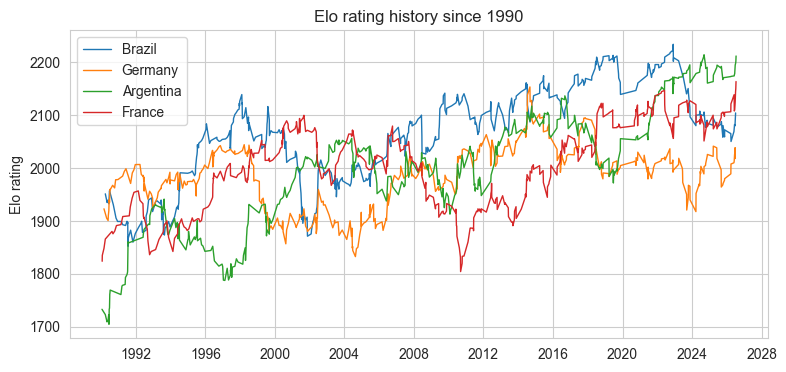

In [10]:
#To watch a few famous teams' ratings rise and fall over time
fig, ax = plt.subplots(figsize=(9, 4))

#Loop through each team of interest to create an individual line for them
for team in ["Brazil", "Germany", "Argentina", "France"]:

    #Extract all matches for this specific team (whether they played home or away)
    hist = df[(df.home_team == team) | (df.away_team == team)].copy()

    #Create a new column 'team_elo' that picks the correct pre-match rating 
    # based on whether the team was the 'home_team' or 'away_team' in that row
    hist["team_elo"] = np.where(hist.home_team == team, hist.home_elo_pre, hist.away_elo_pre)

    #Only look at the data from 1990 onwards for a cleaner, modern view and Draw the line for this team using the date as the X-axis and Elo as the Y-axis
    hist = hist[hist.date >= "1990-01-01"]
    ax.plot(hist.date, hist.team_elo, label=team, linewidth=1)

ax.set_title("Elo rating history since 1990")
ax.set_ylabel("Elo rating")
ax.legend()
plt.show()

Notice the ratings aren't flat, they visibly dip and climb around major tournaments (World Cups happen roughly every 4 years, and you can often spot them as bigger swings, since results in high-stakes tournament matches move the rating more than a friendly). This confirms Elo is actually picking up real momentum/form changes over time, not just settling at a fixed number which is exactly the "current strength" signal we need for prediction.

**Step 6: Preparing training and test data**

6a. Defining the target
We turn "home win / draw / away win" into numbers:
`0` = away win, `1` = draw, `2` = home win

`df.apply(function, axis=1)` runs `function` once per row and collects the results into a new column.

In [11]:
def outcome(row):
    if row.home_score > row.away_score:
        return 2
    elif row.home_score < row.away_score:
        return 0
    return 1

df["result"] = df.apply(outcome, axis=1)
df["result"].value_counts()

result
2    24264
0    13996
1    11258
Name: count, dtype: int64

These counts should match the proportions from Step 4's chart, just as raw numbers instead of percentages, a quick way to confirm the target column was built correctly (nothing was silently dropped or miscounted along the way).

6b. Restricting to recent matches
Football in 1880 played very differently to 2020. We only train on matches from 2000 onwards.

In [12]:
model_df = df[df.date >= "2000-01-01"].copy()
print("Rows available for modelling:", len(model_df))

Rows available for modelling: 25456


This filter cuts the dataset down substantially compared to the ~49,500 total rows. A reminder that "more historical data" isn't automatically better. Trading data volume for *relevance* is a real modelling decision, and it's one you should be able to justify out loud (here: the game itself, fitness, tactics, squad depth has changed enough that 19th-century matches would mostly add noise).

**6c. Train/test split BUT why NOT `train_test_split()` here**

```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```
That **randomly** shuffles rows into 80% train / 20% test (`test_size=0.2`), with `random_state=42` fixing the shuffle for reproducibility.

**But our data is time-ordered and random shuffling would leak the future into the past**, for example, a 2023 match could end up training a model tested on a 2015 match. That gives an unrealistically good score.
Fix: split **chronologically** by hand.

In [13]:
#AN IDEA FOR FUTURE, TO MAYBE TEST ON MORE PROMINENT FEATURES AS WELL TO HELP THE MODEL LEARN INSTEAD OF JUST ELO RATINGS, LIKE WINNING STREAKS, GOAL DIFFERENCE, ETC, BUT CHANCE OF OVERFITTING
FEATURES = ["home_elo_pre", "away_elo_pre", "elo_diff", "neutral"]
TARGET = "result"

#This prevents 'data leakage' we train on the past to predict the future and split date manually
train = model_df[model_df.date < "2022-01-01"]
test = model_df[(model_df.date >= "2022-01-01") & (model_df.date < "2026-01-01")]


#Separate Features from Targets: Create the final arrays the model will use
# X represents the data the model sees, y represents the outcomes it tries to learn
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Train: {len(train)} matches, {train.date.min().date()} to {train.date.max().date()}")
print(f"Test:  {len(test)} matches, {test.date.min().date()} to {test.date.max().date()}")

Train: 20778 matches, 2000-01-04 to 2021-12-31
Test:  4257 matches, 2022-01-01 to 2025-12-31


The train set is much larger than the test set here, which is expected and fine, what matters isn't a strict 80/20 ratio but that the split boundary is a clean date cutoff. The test window conveniently includes the real 2022 World Cup, which means our "test accuracy" later isn't just abstract but it reflects how the model would've performed on an actual major tournament it never trained on.

**Step 7: Training your first model**

We'll compare two classifiers:
**Logistic Regression** - despite the name, this is a *classification* algorithm. Simple, fast, good first try.
**Random Forest** - many decision trees on random subsets of data, votes averaged. Strong default for tabular data.

#The scikit-learn pattern (same for almost every model)
1. `model = SomeModel(...)`
2. `model.fit(X_train, y_train)`
3. `model.predict(X_test)` or `model.predict_proba(X_test)`

Always start with a **baseline** so you have something concrete to beat

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
# Calculate a naive baseline accuracy by assuming the model always predicts 
# the most frequent (majority) class in the test set.
# This serves as a benchmark: any model performance must exceed this to be useful.
baseline_acc = (y_test == y_test.mode()[0]).mean()
print(f"Baseline (always guess majority class): {baseline_acc:.3f} accuracy")

Baseline (always guess majority class): 0.477 accuracy


In [15]:
# ---- Model 1: Logistic Regression ----
#Initialize and train the Logistic Regression model, setting to 1000 increases the solver iteration limit
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Generate predictions on the test set
logreg_preds = logreg.predict(X_test)

# Evaluate and display accuracy
print(f"\nLogistic Regression accuracy: {accuracy_score(y_test, logreg_preds):.3f}")



# ---- Model 2: Random Forest ----
#Initialize Random Forest with defined hyperparameters and train, 300 is the robust forests, depth of 6 to prevent overfitting, random_state for reproducibility
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

# Generate predictions and display accuracy
rf_preds = rf.predict(X_test)
print(f"Random Forest accuracy: {accuracy_score(y_test, rf_preds):.3f}")



Logistic Regression accuracy: 0.601
Random Forest accuracy: 0.601


Both models comfortably beat the baseline, that's the real proof the Elo features are informative, not just noise dressed up as a feature. Also notice Logistic Regression and Random Forest land pretty close to each other in accuracy. For a relatively simple, low-dimensional feature set like ours (just 4 features), a complex model doesn't automatically win by much so it's often worth trying the simple model first before reaching for something heavier.

**Step 8: Evaluating the model properly**

`log_loss` - how confident AND correct are the predicted probabilities?
Accuracy only checks the top prediction. `log_loss` also punishes overconfident-wrong predictions. Lower is better - matters more for us since we'll use probabilities to simulate a tournament.

`confusion_matrix` - where exactly are the mistakes?
Rows = actual, columns = predicted. Perfect predictions only have numbers on the diagonal.

In [16]:

#Compute log loss using predicted probabilities to evaluate uncertainty
rf_proba = rf.predict_proba(X_test)
print(f"Random Forest log loss: {log_loss(y_test, rf_proba):.3f}")

#Display detailed metrics (precision, recall, F1-score) per outcome category
print(classification_report(y_test, rf_preds, target_names=["away_win", "draw", "home_win"], zero_division=0))

Random Forest log loss: 0.875
              precision    recall  f1-score   support

    away_win       0.56      0.63      0.59      1258
        draw       0.00      0.00      0.00       970
    home_win       0.62      0.87      0.73      2029

    accuracy                           0.60      4257
   macro avg       0.39      0.50      0.44      4257
weighted avg       0.46      0.60      0.52      4257



Look at the `draw` row, precision and recall are both `0.00`. **The model never predicts a draw.** Classic **class imbalance** as draws are the minority outcome, so maximizing accuracy makes it "safer" to never guess draw. In other words the model thinks guessing a draw is too risk so it never does it. This is exactly what Step 4's chart warned us about as a good example of how EDA findings early in a project should predict problems you'll hit later.

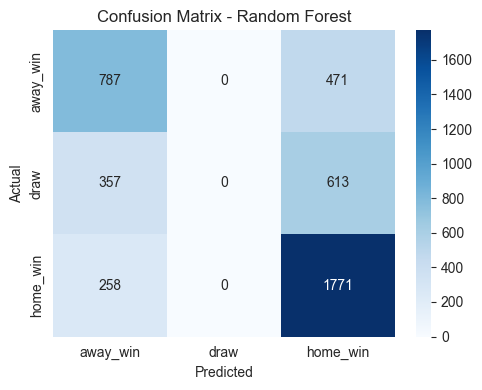

In [17]:
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix to compare actual vs. predicted labels, labels are 0 for loss, 1 for draw and 2 for win
cm = confusion_matrix(y_test, rf_preds, labels=[0, 1, 2])

#Initialize a heatmap figure to visualize the classification results
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["away_win", "draw", "home_win"],
            yticklabels=["away_win", "draw", "home_win"], ax=ax)

#Label axes and title for clarity
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

The `draw` column is essentially empty as visual, unmissable confirmation of the same problem. It's also worth noticing where those missed draws land instead as if actual draws are mostly getting misclassified as home wins rather than being split evenly, that tells you the model still recognizes "this was a close match" (Elo gap was small) and it just isn't confident enough to commit to "draw" as the prediction.

**Step 9: Improving the model**
9a. Fixing class imbalance
`class_weight="balanced"` tells the model to pay more attention to the minority class instead of ignoring it.

In [ ]:
#Initialize Random Forest with 'balanced' class weights to address class imbalance
# This penalizes the model more for misclassifying the minority class (draws)
rf_balanced = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42,class_weight="balanced") #balanced class weights will help the model learn to predict draws better, as they are less frequent in the dataset.

#Train the model and generate predictions on the test set
rf_balanced.fit(X_train, y_train)
balanced_preds = rf_balanced.predict(X_test)

#Display classification metrics to observe if 'balanced' weights improved draw detection
print(classification_report(y_test, balanced_preds, target_names=["away_win", "draw", "home_win"], zero_division=0))

              precision    recall  f1-score   support

    away_win       0.55      0.64      0.59      1258
        draw       0.27      0.24      0.25       970
    home_win       0.71      0.67      0.69      2029

    accuracy                           0.56      4257
   macro avg       0.51      0.52      0.51      4257
weighted avg       0.56      0.56      0.56      4257



Draw recall went from `0.00` to roughly `0.24`, at a small cost to overall accuracy. This is a genuine trade-off, not a free win and its worth stating plainly rather than hiding it. For our use case (simulating a realistic tournament, where group-stage draws happen constantly) that trade-off is worth making and for a use case that only cared about "who wins" and didn't need draws modelled at all, you might reasonably skip this fix.

**9b. Hyperparameter tuning with `GridSearchCV`**
A **hyperparameter** is a setting chosen before training (e.g. `n_estimators`). `GridSearchCV` tries every combination and keeps the best.

The syntax
`param_grid` = `{parameter_name: [values to try]}`
`TimeSeriesSplit(n_splits=5)` = time-safe cross-validation, never validates on data before its training fold
`scoring="neg_log_loss"` = pick the combo with lowest log loss (negated because sklearn scoring is "higher is better")
`grid.best_estimator_` = the already-trained best model

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

#Define a grid of hyperparameters to evaluate during the search
param_grid = {
    "n_estimators": [200, 400], #Number of trees
    "max_depth": [4, 6, 8], #Depth of each tree, or how many decisions before the prediction
    "min_samples_leaf": [5, 20], #The clusters of decisions it makes a prediction on, e.g, does our model performbetter on 5 or 20, if 5 then we have strong patterns, if 20 then more broader safer patterns.
}

#Configure GridSearchCV to find the best hyperparameter combination
# estimator: The model to tune (RandomForest with balanced class weights to address data imbalance)
# param_grid: The set of parameters to iterate through
# cv: TimeSeriesSplit ensures validation is performed chronologically to prevent data leakage
# scoring: Uses 'neg_log_loss' to optimize for both prediction accuracy and probability confidence
# n_jobs=-1: Enables parallel processing to speed up computation across all CPU cores
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_log_loss",
    n_jobs=-1,
)

#Execute the search by training on the training data across all parameter combinations
grid.fit(X_train, y_train)

#Display the optimal parameter set identified by the grid search
print("Best hyperparameters found:", grid.best_params_)

# Retrieve the model trained with the best-found parameters
best_rf = grid.best_estimator_

## Generate class predictions and probability estimates using the optimized model
best_preds = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)

## Report final model performance metrics
print(f"Final accuracy: {accuracy_score(y_test, best_preds):.3f}")
print(f"Final log loss: {log_loss(y_test, best_proba):.3f}")

Best hyperparameters found: {'max_depth': 6, 'min_samples_leaf': 20, 'n_estimators': 400}
Final accuracy: 0.563
Final log loss: 0.906


Compare these numbers to the untuned `rf_balanced` model above, the improvement from tuning is usually modest (a few tenths of a point), not dramatic. That's a realistic and worth-stating result: hyperparameter tuning squeezes out incremental gains on top of good features and a sound pipeline, it doesn't rescue a fundamentally weak feature set. If tuning had produced a huge jump, that would actually be a reason to double check the pipeline for a bug like a data leak.

**9c. Which features matter most?**
`.feature_importances_` is a NumPy array lined up with `FEATURES`.

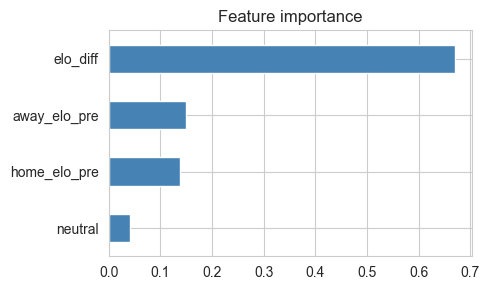

In [24]:

# Create a Series from model feature importances, using the list of feature names 
# ('FEATURES') as the index so each score is labeled with its corresponding metric.
# .sort_values() then rearranges these from lowest to highest importance.
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values()

# Plot the sorted importance scores, 'kind="barh"' creates horizontal bars,
# which are easier to read when you have long feature name labels.
fig, ax = plt.subplots(figsize=(5, 3))
importances.plot(kind="barh", ax=ax, color="steelblue")

# Set chart title and adjust layout for readability using tight_layout to fit in the labels from being cut off.
ax.set_title("Feature importance")
plt.tight_layout()
plt.show()

The raw Elo ratings and their difference dominate, which is a good sanity check, since Step 5's whole purpose was building exactly that signal. If `neutral` had come out on top instead, that would be a red flag that something's wrong with the pipeline (a single binary flag shouldn't outweigh two continuous, purpose-built strength scores).

**Step 10: Using the model to simulate a real tournament**

Monte Carlo simulation
Simulate the rest of the tournament **thousands of times**, each time randomly deciding matches by the model's probabilities. Whoever wins champion most often is our estimate of the true odds.

`joblib.dump(model, path)` saves a trained model to disk for reuse without retraining.

In [ ]:
#Save the trained 'best_rf' model to a disk file named 'wc_model.pkl'.
#'joblib' is a library optimized for serializing large Python objects like scikit-learn models.
import joblib
joblib.dump(best_rf, "wc_model.pkl")

def predict_match(team_a, team_b, neutral=True):
    """Returns the win probability for team_a and team_b in a single match."""
    #Create a DataFrame containing the input features for the model.
    # The model expects a 2D structure, so we pass a list of one dictionary.
    row = pd.DataFrame([{
        "home_elo_pre": elo[team_a],
        "away_elo_pre": elo[team_b],
        "elo_diff": elo[team_a] - elo[team_b],
        "neutral": int(neutral),
    }])

    # Use the trained model to get class probabilities.
    # predict_proba returns an array of shape (1, 3) because we have 3 classes (away_win, draw, home_win).
    # We use [0] to extract the first (and only) row of probabilities.
    p_away, p_draw, p_home = best_rf.predict_proba(row)[0]

    # Knockout matches can't draw - split draw probability proportionally.
    # This logic redistributes the 'draw' probability to both teams based on their relative win probabilities.
    # If a team had a higher win chance, they receive a larger share of the redistributed draw chance.
    p_a = p_home + p_draw * (p_home / (p_home + p_away))
    p_b = p_away + p_draw * (p_away / (p_home + p_away))
    return p_a, p_b

# Call the function for specific matchups
p_fra, p_esp = predict_match("France", "Spain")
p_eng, p_arg = predict_match("England", "Argentina")

print(f"Semifinal - France vs Spain:      France {p_fra:.1%}  |  Spain {p_esp:.1%}")
print(f"Semifinal - England vs Argentina: England {p_eng:.1%}  |  Argentina {p_arg:.1%}")


Semifinal - France vs Spain:      France 25.0%  |  Spain 75.0%
Semifinal - England vs Argentina: England 22.5%  |  Argentina 77.5%


Whichever team is favored here should line up with the Elo gap you'd see if you looked up both teams from Step 5's ratings, the bigger the Elo difference, the more lopsided the probability split. If a much lower-rated team came out as heavily favored, that's a sign to go back and check the `predict_match` logic rather than trust the output blindly.

 Only 4 possible finals can happen, so we precompute those odds once, then simulate.

 The syntax
`np.random.seed(42)` fixes randomness for reproducibility
`np.random.random((N, 3))` = N x 3 grid of random numbers 0-1 (one "coin flip" per match per simulation)
`rand[i, 0] < p_fra` is True with probability `p_fra` turns a random number into a weighted coin flip

In [27]:
# Dictionary 'finals' maps potential final matchups to their pre-calculated win probabilities
# Using the predict_match function, we get a tuple (p_a, p_b) for every pairing
finals = {
    ("France", "England"): predict_match("France", "England"),
    ("France", "Argentina"): predict_match("France", "Argentina"),
    ("Spain", "England"): predict_match("Spain", "England"),
    ("Spain", "Argentina"): predict_match("Spain", "Argentina"),
}

# Monte Carlo simulation setup
np.random.seed(42) # Ensures the "random" results are reproducible every time you run this
N = 20_000 # Number of tournament simulations to run

# Generate a giant matrix of random floats between 0 and 1.
# (N, 3) means 20,000 rows and 3 columns. Column 0 for SF1, Column 1 for SF2, Column 2 for Final.
rand = np.random.random((N, 3)) 
champion_count = {} # Dictionary to store how many times each team wins the simulation

# Run the simulation N times
for i in range(N):
    # Determine Semifinal 1 winner: if random roll is less than France's win probability, France wins
    sf1_winner = "France" if rand[i, 0] < p_fra else "Spain"
    # Determine Semifinal 2 winner: similar logic for the second semifinal
    sf2_winner = "England" if rand[i, 1] < p_eng else "Argentina"

    # Retrieve pre-calculated win probabilities for the specific final matchup
    pf1, pf2 = finals[(sf1_winner, sf2_winner)]

    # Determine the Champion: compare the random roll (Column 2) against the first finalist's win prob
    champion = sf1_winner if rand[i, 2] < pf1 else sf2_winner

    # Increment the champion's count in our dictionary
    champion_count[champion] = champion_count.get(champion, 0) + 1

print(f"Simulated FIFA World Cup 2026 champion probabilities, from {N:,} simulations:")

# Sort by count (descending) to show the most likely champions first
for team, count in sorted(champion_count.items(), key=lambda x: -x[1]):
    print(f"  {team}: {count/N:.1%}")

Simulated FIFA World Cup 2026 champion probabilities, from 20,000 simulations:
  Argentina: 50.4%
  Spain: 31.5%
  England: 9.7%
  France: 8.4%


No team gets close to 100%,  even the favorite typically sits well under a coin-flip-plus, which is realistic as knockout football is genuinely uncertain, and a good model should reflect that uncertainty rather than pretend to be more sure than it is. This is also the clearest illustration of why we optimized for log loss (well-calibrated probabilities) back in Step 9, rather than only accuracy a simulation built on overconfident probabilities would produce a far less trustworthy spread of outcomes.


**Summary and where to go next**

 **What we built:**
1. Identified this as classification, not regression
2. Downloaded and cleaned real data (actual nulls, actual duplicates)
3. Explored the data before modelling
4. Engineered a feature from scratch (Elo ratings)
5. Split data correctly for time-ordered problems
6. Trained and compared two classifiers
7. Evaluated with multiple metrics and diagnosed class imbalance
8. Fixed it and tuned hyperparameters with GridSearchCV
9. Turned the model into a Monte Carlo tournament simulator

**Ideas to extend:**
Add features: recent form, squad value, injuries, goals scored/conceded averages
Try XGBoost/LightGBM vs Random Forest
Predict exact scorelines with Poisson regression
Simulate the full tournament from the group stage
#Wrap `predict_match()` in a Streamlit app

In [32]:
#Test on the world cup finals
p_arg, p_esp = predict_match("Argentina", "Spain")
print(f"Final - Argentina vs Spain: Argentina {p_arg:.1%}  |  Spain {p_esp:.1%}")

Final - Argentina vs Spain: Argentina 33.1%  |  Spain 66.9%


In [ ]:
#Test on the games
p_fra, p_eng = predict_match("France", "England")
print(f"Final - France vs England: France {p_fra:.1%}  |  England {p_eng:.1%}")

Final - France vs England: France 46.4%  |  England 53.6%


In [34]:
#Test on the games
p_por, p_spa = predict_match("Portugal", "Spain")
print(f"Final - Portugal vs Spain: Portugal {p_por:.1%}  |  Spain {p_spa:.1%}")

Final - Portugal vs Spain: Portugal 20.0%  |  Spain 80.0%


In [35]:
#Test on the games
p_nor, p_eng = predict_match("Norway", "England")
print(f"Final - Norway vs England: Norway {p_nor:.1%}  |  England {p_eng:.1%}")

Final - Norway vs England: Norway 24.0%  |  England 76.0%
